# M48 Tier A - seed band, selection criterion, feature-extractor null

Three ablation rows the M45 table could not answer, on the **corrected official 60/40
patient-independent split**, using `Asif's/M45/m45_ablation.py` for data, preprocessing,
caching and metrics **without modifying it**.

| Row | What it is | Why it is needed |
|---|---|---|
| `A0_s42` `A0_s1` `A0_s2` | the same config three times | M45 ran one seed per row. Ten of eleven rows come back *not shown to differ from A0*. Their spread is the noise floor every M45 delta must clear. |
| `A7` (free, every row) | checkpoint by official score **vs** by minimum loss | The paper argues the selection criterion matters and reports a 33-epoch disagreement, but never puts a number on it. Both criteria are tracked in one loop, so this costs no extra training. |
| `A24` | random init **and** frozen backbone | A4 froze a *pretrained* backbone, so its $-0.1007$ mixes *fine-tuning helps* with *pretraining helps*. This separates them. |

**Runtime:** ~15 min to build the spectrogram cache once, then ~18 min per row on a T4.
All four rows share one cache key, so the cache is built once. Budget **~90 minutes**.

**Attach before running:**
1. GPU accelerator (Settings -> Accelerator -> GPU T4 x2 or P100).
2. The ICBHI 2017 dataset - search Kaggle for *Respiratory Sound Database* and Add Data.
3. Internet ON (the notebook clones the repo, and torchvision downloads ImageNet weights).

**One caveat that must travel with A7:** `m45_ablation.py` monitors the **test** set each
epoch; there is no separate validation split. So *select on loss* here means select on
test loss. That is optimistic, and equally so for every row, so the seed band and the
A24 delta are unaffected - but A7 must be reported as *two criteria on one monitoring
set*, never as a clean train/val/test result.


## 1 - Environment and repository


In [2]:
import os, sys, glob, subprocess, json

REPO = '/kaggle/working/CSE465-Project-OWMTL'
if not os.path.isdir(REPO):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/barshon-basak/CSE465-Project-OWMTL.git',
                    REPO], check=True)
M48 = os.path.join(REPO, 'M48_core_pipeline_ablation')
M45 = os.path.join(REPO, "Asif's", 'M45')
assert os.path.exists(os.path.join(M45, 'm45_ablation.py')), 'm45_ablation.py missing'
assert os.path.exists(os.path.join(M48, 'm48_gpu_rows.py')), 'm48_gpu_rows.py missing'
print('repo ok')

import torch
print('torch', torch.__version__, '| cuda', torch.cuda.is_available(), '|',
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU ONLY')
assert torch.cuda.is_available(), 'Enable the GPU accelerator before running.'


Cloning into '/kaggle/working/CSE465-Project-OWMTL'...
Updating files: 100% (658/658), done.


repo ok
torch 2.10.0+cu128 | cuda True | Tesla T4


## 2 - Locate the ICBHI audio and the official split file

Found by content, not by a hard-coded path, so any Kaggle mirror of this corpus works.
The cell **fails loudly** if it cannot find them - a silent fallback to a wrong split is
the exact fault this project's paper is about.


In [3]:
def find_audio_dir():
    hits = glob.glob('/kaggle/input/**/101_1b1_Al_sc_Meditron.wav', recursive=True)
    return os.path.dirname(hits[0]) if hits else None


def find_split_file():
    hits = glob.glob('/kaggle/input/**/ICBHI_challenge_train_test.txt', recursive=True)
    hits += glob.glob(os.path.join(REPO, '**', 'ICBHI_challenge_train_test.txt'),
                      recursive=True)
    return hits[0] if hits else None


AUDIO = find_audio_dir()
SPLIT = find_split_file()
if AUDIO is None:
    raise SystemExit('ICBHI audio not found. Add Data, search for the Respiratory '
                     'Sound Database, attach it, then re-run this cell.')
if SPLIT is None:
    raise SystemExit('ICBHI_challenge_train_test.txt not found in any input or the repo.')

n_wav = len(glob.glob(os.path.join(AUDIO, '*.wav')))
n_txt = len(glob.glob(os.path.join(AUDIO, '*.txt')))
print('audio dir :', AUDIO)
print('split file:', SPLIT)
print(f'{n_wav} wav / {n_txt} txt')
assert n_wav == 920, f'expected 920 recordings, found {n_wav}'

os.environ['ICBHI_AUDIO_DIR'] = AUDIO
os.environ['ICBHI_SPLIT_FILE'] = SPLIT
os.environ['M45_DIR'] = M45
os.environ['M48_CACHE_DIR'] = '/kaggle/working/m48_cache'
os.makedirs(os.environ['M48_CACHE_DIR'], exist_ok=True)


audio dir : /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
split file: /kaggle/input/datasets/sudamchandrabasak/icbhi-challenge-train-test-split/ICBHI_challenge_train_test.txt
920 wav / 920 txt


## 3 - Wiring self-test (no GPU, no audio, ~2 s)

Checks the three things that would silently waste the session: that every row differs
from the M45 baseline in exactly the fields it names, that the three A0 replicates differ
**only** in the seed, and that all four rows share one cache key so no row trains on
another row's spectrograms. **Do not proceed on a FAIL.**


In [4]:
!cd "$M48" && python m48_gpu_rows.py --selftest


  m45_ablation imported from /kaggle/working/CSE465-Project-OWMTL/Asif's/M45
  m45.corrected_split_index  ok
  m45.build_cache            ok
  m45.official               ok
  m45.patient_ci             ok
  m45.BASE                   ok
  A0_s42   changes ['(none — same as BASE)']
  A0_s1    changes ['seed']
  A0_s2    changes ['seed']
  A24      changes ['freeze', 'pretrained']
  A0 replicates differ only in: ['seed']  (want ['seed'])
  cache keys across all M48 rows: 1 (want 1 — no row changes the pixels)

  SELFTEST PASS


## 4 - Verify the corrected split before spending an hour on it

551/369 recordings, patients 156 and 218 reassigned to train, zero patient overlap.


In [5]:
sys.path.insert(0, M45)
import m45_ablation as m45

rows = m45.corrected_split_index(AUDIO, SPLIT)
tr = [r for r in rows if r['split'] == 'train']
te = [r for r in rows if r['split'] == 'test']
ptr = {r['patient_id'] for r in tr}
pte = {r['patient_id'] for r in te}
print(f'cycles   train {len(tr)} / test {len(te)}  (total {len(rows)})')
print(f'patients train {len(ptr)} / test {len(pte)}')
print('patient overlap:', sorted(ptr & pte) or 'none')
assert not (ptr & pte), 'patient leakage - stop and fix the split before training'
assert len(te) == 2636, f'expected 2636 test cycles, got {len(te)}'
print()
print('split verified: matches the paper (4,251 train / 2,636 test, 79 / 47 patients)')


cycles   train 4251 / test 2636  (total 6887)
patients train 79 / test 47
patient overlap: none

split verified: matches the paper (4,251 train / 2,636 test, 79 / 47 patients)


## 5 - Run the four rows

The first row builds the spectrogram cache (~15 min); the other three reuse it. Rows that
already have a `results_M48_*.json` are skipped, so re-running this cell after a session
timeout resumes rather than restarts.


In [6]:
!cd "$M48" && python m48_gpu_rows.py --all


  m45_ablation imported from /kaggle/working/CSE465-Project-OWMTL/Asif's/M45
  cycles 6887 | test 2636
  rows to run: ['A0_s42', 'A0_s1', 'A0_s2', 'A24']

  A0_s42: A0 baseline re-run under the M48 harness (seed 42)
  device cuda | seed 42
    building cache train_128m_8.0s_wrap_1_bp0_dn0_an0.npy ...
      1500/4251
      3000/4251
    building cache test_128m_8.0s_wrap_1_bp0_dn0_an0.npy ...
      1500/2636
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|███████████████████████████████████████| 13.6M/13.6M [00:00<00:00, 111MB/s]
/kaggle/working/CSE465-Project-OWMTL/M48_core_pipeline_ablation/m48_gpu_rows.py:199: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  run += float(loss) * len(y)
    ep 05/40  

## 6 - Summary table

`M48_tier_A_table.json` carries the seed band, the A7 deltas and the A24 row. The second
half of this cell is the point of the whole notebook: it reads every M45 delta against the
measured band and says which ones survive it.


In [7]:
!cd "$M48" && python m48_gpu_rows.py --summarise

t = json.load(open(os.path.join(M48, 'M48_tier_A_table.json')))
b = t['seed_band']
if b:
    print()
    print(f"SEED BAND  mean {b['mean']:.4f}  sd {b['sd']:.4f}  range {b['range']:.4f}")
    print(f"M45 deltas smaller than {b['range']:.4f} are inside run-to-run noise:")
    m45_deltas = {'A1': -0.0402, 'A2': -0.0603, 'A3': -0.0105, 'A4': -0.1007,
                  'A5': -0.0175, 'A6': -0.0378, 'P1': -0.0089, 'P2': -0.0354,
                  'P3': +0.0162, 'P4': -0.0311, 'P5': -0.0063}
    for k, v in sorted(m45_deltas.items(), key=lambda kv: -abs(kv[1])):
        mark = 'clears the band' if abs(v) > b['range'] else 'INSIDE seed noise'
        print(f'  {k}  {v:+.4f}   {mark}')



  M48 TIER A — completed rows: A0_s1, A0_s2, A0_s42, A24
  SEED BAND   mean 0.5626  sd 0.0075  range 0.0141  over seeds [42, 1, 2]
              M45's A0 reference is 0.5602
  A7 A0_s1    by score 0.5681  by loss 0.4666  delta +0.1015  (19 epochs apart)
  A7 A0_s2    by score 0.5657  by loss 0.4665  delta +0.0992  (17 epochs apart)
  A7 A0_s42   by score 0.5540  by loss 0.4788  delta +0.0752  (15 epochs apart)
  A7 A24      by score 0.4979  by loss 0.4979  delta +0.0000  (0 epochs apart)
  A2+A4       0.4979  vs A0 -0.0623  (A2 alone 0.4999, A4 alone 0.4595)
  wrote M48_tier_A_table.json

SEED BAND  mean 0.5626  sd 0.0075  range 0.0141
M45 deltas smaller than 0.0141 are inside run-to-run noise:
  A4  -0.1007   clears the band
  A2  -0.0603   clears the band
  A1  -0.0402   clears the band
  A6  -0.0378   clears the band
  P2  -0.0354   clears the band
  P4  -0.0311   clears the band
  A5  -0.0175   clears the band
  P3  +0.0162   clears the band
  A3  -0.0105   INSIDE seed noise
  P1 

## 7 - Training curves

The two selection criteria on one axis. If the marked epochs are far apart, that gap is
the A7 finding; if the two scores end up close, the criterion did not matter and the
paper should say so.

The train-accuracy series is measured **under augmentation** (taken from the forward pass
the training loop already runs), so it sits below a clean-pass number by construction.


Skipping 1 file(s) missing training_history: ['results_M48_C4.json']
(these rows likely need to be re-run — see cell 5)

A0_s1    by score 0.5681 @ep25   by loss 0.4666 @ep6   A7 delta +0.1015
A0_s2    by score 0.5657 @ep21   by loss 0.4665 @ep4   A7 delta +0.0992
A0_s42   by score 0.5540 @ep23   by loss 0.4788 @ep8   A7 delta +0.0752
A24      by score 0.4979 @ep12   by loss 0.4979 @ep12   A7 delta +0.0000


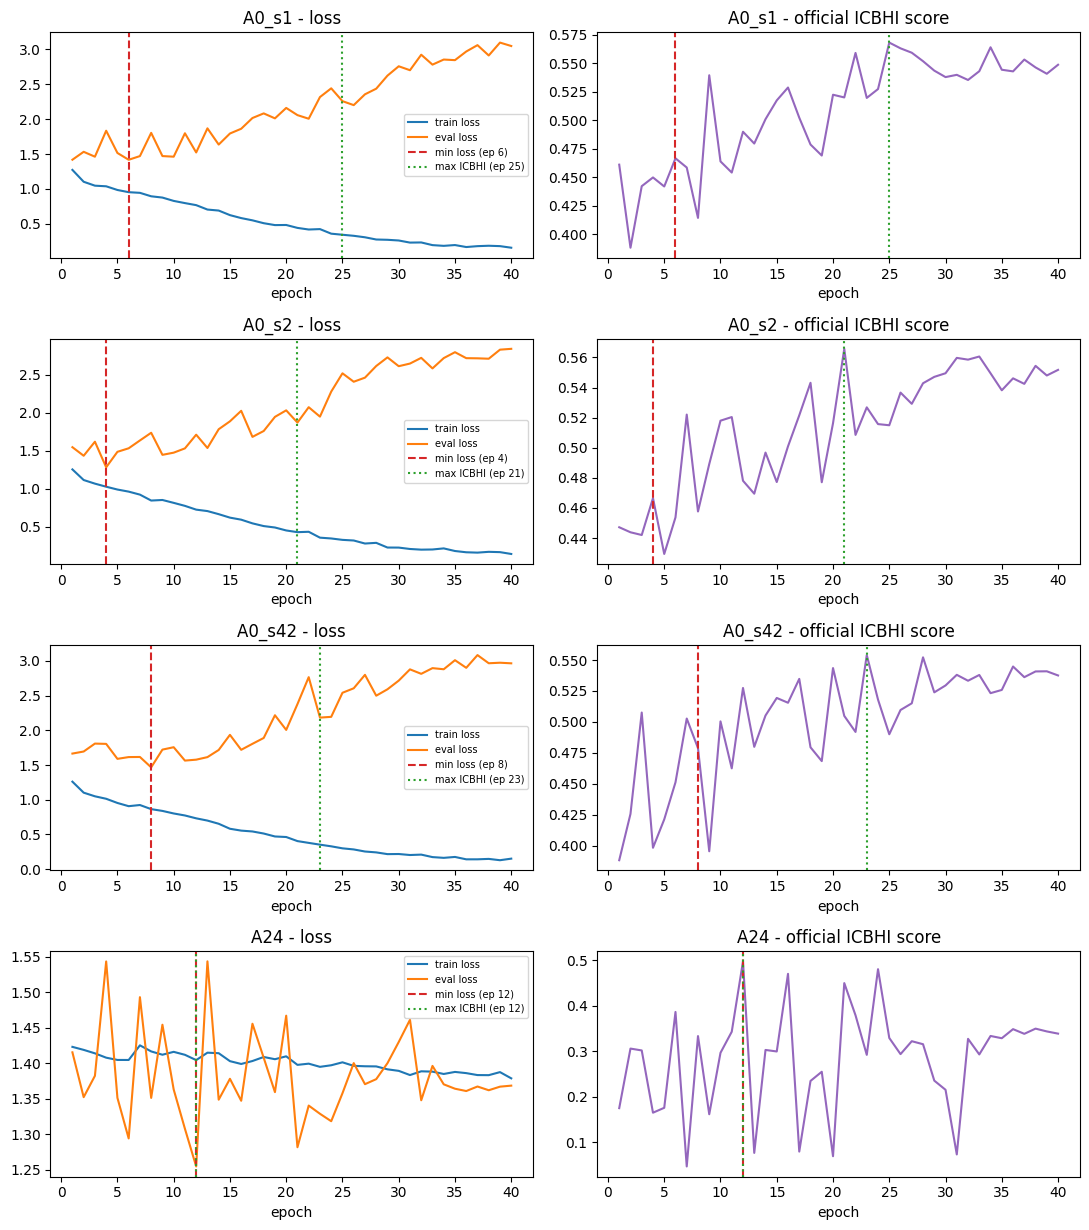

In [9]:
import matplotlib.pyplot as plt

all_files = sorted(glob.glob(os.path.join(M48, 'results_M48_*.json')))
files, skipped = [], []
for f in all_files:
    d = json.load(open(f))
    if 'training_history' in d:
        files.append(f)
    else:
        skipped.append(os.path.basename(f))

if skipped:
    print(f"Skipping {len(skipped)} file(s) missing training_history: {skipped}")
    print("(these rows likely need to be re-run — see cell 5)\n")

if files:
    fig, axes = plt.subplots(len(files), 2, figsize=(11, 3.1 * len(files)), squeeze=False)
    for ax_row, f in zip(axes, files):
        d = json.load(open(f))
        h = d['training_history']
        ep = [e['epoch'] for e in h]
        sel = d['selection']
        e_sc = sel['by_official_score']['epoch']
        e_ls = sel['by_min_eval_loss']['epoch']

        a = ax_row[0]
        a.plot(ep, [e['train_loss'] for e in h], label='train loss')
        a.plot(ep, [e['eval_loss'] for e in h], label='eval loss')
        a.axvline(e_ls, ls='--', c='tab:red', label=f'min loss (ep {e_ls})')
        a.axvline(e_sc, ls=':', c='tab:green', label=f'max ICBHI (ep {e_sc})')
        a.set_xlabel('epoch')
        a.set_title(d['meta']['row'] + ' - loss')
        a.legend(fontsize=7)

        b2 = ax_row[1]
        b2.plot(ep, [e['icbhi_score_official'] for e in h], c='tab:purple')
        b2.axvline(e_ls, ls='--', c='tab:red')
        b2.axvline(e_sc, ls=':', c='tab:green')
        b2.set_xlabel('epoch')
        b2.set_title(d['meta']['row'] + ' - official ICBHI score')

        print(f"{d['meta']['row']:<8} by score "
              f"{sel['by_official_score']['icbhi_score_official']:.4f} @ep{e_sc}   "
              f"by loss {sel['by_min_eval_loss']['icbhi_score_official']:.4f} @ep{e_ls}   "
              f"A7 delta {sel['A7_delta_score_minus_loss']:+.4f}")
    plt.tight_layout()
    plt.savefig(os.path.join(M48, 'M48_selection_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No rows had training_history — nothing to plot. Check the skipped files above.")

## 8 - Collect the outputs

Download `M48_results.zip` from the notebook's Output panel and unzip it into
`M48_core_pipeline_ablation/` in the repo, then commit. Checkpoints and the spectrogram
cache are deliberately excluded - the cache is regenerable and the JSONs carry every
number, including the raw confusion matrix each row is scored from.


In [10]:
import zipfile

keep = (sorted(glob.glob(os.path.join(M48, 'results_M48_*.json')))
        + sorted(glob.glob(os.path.join(M48, 'preds_M48_*.npy')))
        + sorted(glob.glob(os.path.join(M48, 'M48_tier_A_table.json')))
        + sorted(glob.glob(os.path.join(M48, 'M48_selection_curves.png'))))
out = '/kaggle/working/M48_results.zip'
with zipfile.ZipFile(out, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in keep:
        z.write(f, os.path.basename(f))
        print(f'  {os.path.basename(f):<38} {os.path.getsize(f)/1024:8.1f} KB')
print()
print(f'wrote {out}  ({os.path.getsize(out)/1024:.1f} KB, {len(keep)} files)')


  results_M48_A0_s1.json                     11.5 KB
  results_M48_A0_s2.json                     11.5 KB
  results_M48_A0_s42.json                    11.6 KB
  results_M48_A24.json                       11.5 KB
  results_M48_C4.json                         6.7 KB
  preds_M48_A0_s1.npy                        82.9 KB
  preds_M48_A0_s2.npy                        82.9 KB
  preds_M48_A0_s42.npy                       82.9 KB
  preds_M48_A24.npy                          62.2 KB
  M48_tier_A_table.json                       1.8 KB
  M48_selection_curves.png                  366.9 KB

wrote /kaggle/working/M48_results.zip  (370.3 KB, 11 files)
